# 07 Image Processing and Feature Extraction

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load or create a small image and inspect its shape and range
- Resize, normalize, and convert color (e.g. grayscale) as preprocessing steps
- Apply a simple feature extraction step (e.g. edge detection) and compare with the original
- Visualize original vs processed image with clear axis labels

---

## 🌍 Real life

**Where is this used?** Image processing and feature extraction are used in **medical imaging**, **autonomous driving** (lane/object edges), and **document scanning** (e.g. receipt digitization). Before feeding images into a CNN, we usually resize, normalize, and sometimes extract hand-crafted features for analysis.

**In this notebook we use** basic **image processing** (resize, normalize, grayscale) and **edge detection** to **prepare and understand image data**. We use **filters and feature extraction** (instead of raw pixels only) **because** edges and structure help both classical computer vision and deep learning; CNNs later learn similar filters automatically.

**📌 Covers slide(s):** **10** — Image Processing Basics (pixels, RGB/grayscale, augmentation). *Do this notebook after that slide; bridges to Unit 2 CNNs.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Image** = 2D (grayscale) or 3D (e.g. RGB) array of numbers (pixels). Values often 0–255; models usually expect normalized (e.g. 0–1).
- **Preprocessing:** Resize to fixed size (e.g. for a model), normalize (divide by 255 or standardize), optionally convert to grayscale to reduce channels.
- **Feature extraction:** Edges (Sobel, Canny), textures, histograms. We use edges here as a simple example; CNNs learn their own features from data.
- **Pipeline:** Load image → resize → normalize → (optional) grayscale → optional hand-crafted features → feed to model or visualize.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, OpenCV (`cv2`). We create a small synthetic image (no external file) so the notebook runs anywhere.

**Dataset:** Synthetic — small random image (no download; used to demonstrate preprocessing and edge detection).

**Outputs:** Printed image shape and dtype, one figure with two subplots: **original (resized, normalized)** and **edge map**, with clear axis labels and titles.


In [1]:
# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("✅ NumPy, Matplotlib, OpenCV ready.")

✅ NumPy, Matplotlib, OpenCV ready.


## Step 2: Create a small synthetic image (no external file)

In [2]:
# We use a synthetic image so the notebook runs without downloading files; in real life you'd load from disk or a dataset.
np.random.seed(42)
img = np.random.randint(0, 256, (64, 64), dtype=np.uint8)
# Add a simple "shape" (rectangle) so edges are visible
img[16:48, 16:48] = 180
print("Image shape:", img.shape, "dtype:", img.dtype)
print("Pixel range:", img.min(), "-", img.max())

Image shape: (64, 64) dtype: uint8
Pixel range: 0 - 255


## Step 3: Resize and normalize (typical preprocessing for deep learning)

In [3]:
# Resize to a common size; normalize to 0-1 so models train stably.
img_resized = cv2.resize(img, (32, 32))
img_normalized = img_resized.astype(np.float32) / 255.0
print("Resized shape:", img_resized.shape)
print("Normalized range: %.2f - %.2f" % (img_normalized.min(), img_normalized.max()))

Resized shape: (32, 32)
Normalized range: 0.08 - 0.89


## Step 4: Edge detection (we use Sobel instead of raw pixels to highlight structure)

In [4]:
# We use Sobel to extract edges; CNNs later learn similar filters from data.
sobelx = cv2.Sobel(img_resized, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_resized, cv2.CV_64F, 0, 1, ksize=3)
edges = np.sqrt(sobelx**2 + sobely**2)
edges = np.clip(edges, 0, 255).astype(np.uint8)
print("Edge map shape:", edges.shape)

Edge map shape: (32, 32)


## Step 5: Visualize original and edge map

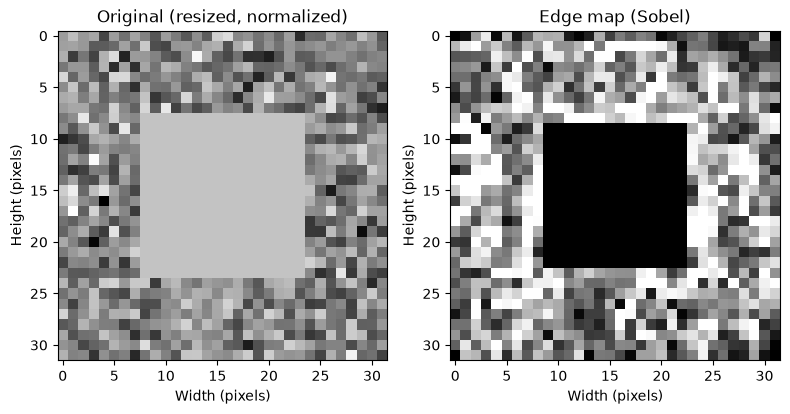

✅ Original vs edge map plotted.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(img_normalized, cmap="gray")
ax1.set_xlabel("Width (pixels)")
ax1.set_ylabel("Height (pixels)")
ax1.set_title("Original (resized, normalized)")
ax2.imshow(edges, cmap="gray")
ax2.set_xlabel("Width (pixels)")
ax2.set_ylabel("Height (pixels)")
ax2.set_title("Edge map (Sobel)")
plt.tight_layout()
plt.show()
print("✅ Original vs edge map plotted.")

## 🌍 Real-World Worked Example — House Price Prediction (Manual Backprop)

**Industry context:** Real estate platforms (Zillow, Property Finder) use regression models  
trained with gradient descent to estimate property prices.

Below we implement a 1-hidden-layer network **with manual backpropagation** to predict house prices.

Final MSE loss: 0.0303


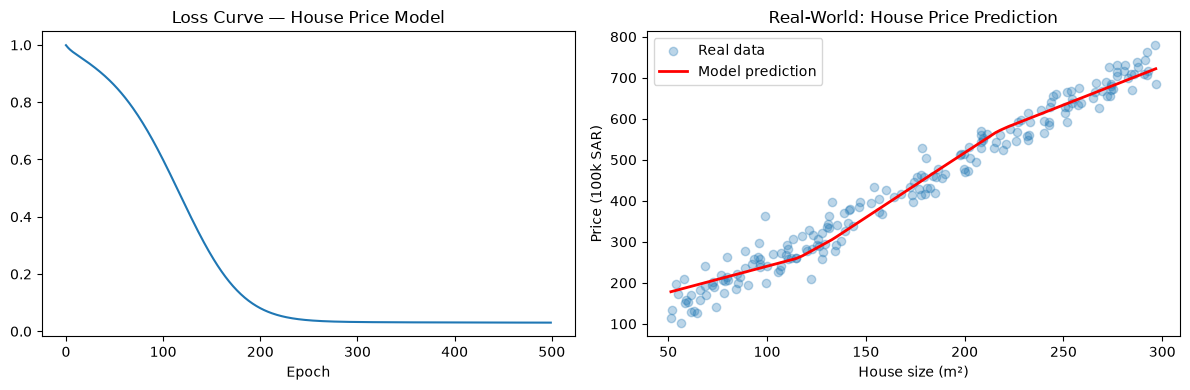

In [6]:
import numpy as np, matplotlib.pyplot as plt

np.random.seed(42)
# ── Synthetic house data (size in m², price in 100k SAR) ──────────────────
n = 200
X = np.random.uniform(50, 300, (n, 1)).astype(np.float32)       # size
y = (2.5 * X + np.random.randn(n,1)*30).astype(np.float32)      # price

# Normalise
X_n = (X - X.mean()) / X.std()
y_n = (y - y.mean()) / y.std()

# ── Manual 1-layer network ─────────────────────────────────────────────────
def relu(z): return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)

W1 = np.random.randn(1, 16) * 0.1;  b1 = np.zeros((1, 16))
W2 = np.random.randn(16, 1) * 0.1;  b2 = np.zeros((1, 1))
lr = 0.01;  losses = []

for _ in range(500):
    # Forward
    z1 = X_n @ W1 + b1          # (n, 16)
    a1 = relu(z1)
    z2 = a1 @ W2 + b2            # (n, 1)
    loss = ((z2 - y_n)**2).mean()
    losses.append(loss)

    # ── Backpropagation (chain rule, step by step) ─────────────────────────
    dL_dz2 = 2*(z2 - y_n) / n
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = dL_dz2.sum(0, keepdims=True)
    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * relu_d(z1)
    dL_dW1 = X_n.T @ dL_dz1
    dL_db1 = dL_dz1.sum(0, keepdims=True)

    # Gradient descent step
    W2 -= lr * dL_dW2;  b2 -= lr * dL_db2
    W1 -= lr * dL_dW1;  b1 -= lr * dL_db1

print(f"Final MSE loss: {losses[-1]:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses); plt.title("Loss Curve — House Price Model"); plt.xlabel("Epoch")
plt.subplot(1, 2, 2)
pred_y = (relu(X_n @ W1 + b1) @ W2 + b2) * y.std() + y.mean()
plt.scatter(X, y, alpha=0.3, label="Real data")
idx = X[:,0].argsort()
plt.plot(X[idx], pred_y[idx], 'r-', lw=2, label="Model prediction")
plt.xlabel("House size (m²)"); plt.ylabel("Price (100k SAR)"); plt.legend()
plt.title("Real-World: House Price Prediction")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** In a new code cell, create a small 3×3 image (e.g. random or a pattern), normalize it to [0,1], and print its min/max and shape. Then resize it to 28×28 (as for MNIST) and print the new shape.

---

## ✅ Summary

**What you did:**
- Created a small synthetic image and inspected its shape and range.
- Resized and normalized it (typical preprocessing for deep learning).
- Applied Sobel edge detection to extract structure.
- Plotted original vs edge map with clear axis labels and titles.

**In real life you'd also:** Load real images (e.g. from disk or a dataset), use data augmentation, and feed normalized batches into a CNN.

**The main idea:** Preprocessing (resize, normalize) and optional feature extraction (e.g. edges) prepare images for models; CNNs later learn their own filters from data.

**Next:** Unit 2 CNNs use convolutional layers that learn similar edge-like and texture features automatically.

## 📚 References & Further Reading

**Papers:**
- Rumelhart, Hinton & Williams (1986) — [Learning representations by back-propagating errors](https://www.nature.com/articles/323533a0)

**Tutorials:**
- [Andrej Karpathy — micrograd](https://github.com/karpathy/micrograd) (build backprop from scratch in 150 lines)
- [PyTorch Autograd Tutorial](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html)

**State-of-the-Art:** Backpropagation is the engine behind GPT-4, Stable Diffusion, and every modern neural network.